# GSM8K resume-quality analysis

This notebook aggregates the completed sequential-resume GSM8K comparison of
All-HOT and Mixed (WARM INT8) decoding.

Final result root, relative to the repository:

`experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/`

Only the four completed `batch_*` directories under that root are included.
Smoke, preflight, debug, retry, earlier `max_tokens=64`, synchronous-scheduling,
and the failed 100-question attempt are inspected for exclusion and are not
mixed into the quality totals.

The result JSON is the source of record. Companion `*.log` files are used only
for process wall-clock, which the JSON does not store, and as corroboration of
the HOT-to-WARM transitions already implied by the JSON residency fields.


## 1. Paths and plotting style

Paths are resolved from the repository root and then printed relative to it.
Nothing in this notebook writes raw result JSON or reruns the GPU experiment.


In [1]:
from __future__ import annotations

import json
import math
import re
from datetime import datetime
from pathlib import Path

import matplotlib

matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 40)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 140)


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        marker = candidate / "experiments" / "hkv_pressure_study" / "runs"
        if marker.is_dir():
            return candidate
    raise FileNotFoundError(
        "Could not locate experiments/hkv_pressure_study/runs from the working directory."
    )


def rel(path: Path) -> str:
    return str(path.resolve().relative_to(REPO_ROOT))


REPO_ROOT = find_repo_root()
STUDY = REPO_ROOT / "experiments" / "hkv_pressure_study"
RUNS = STUDY / "runs" / "gsm8k_resume_quality"
FINAL_DIR = RUNS / "final_n20_batches5_cap512_seq"
FAILED_DIR = RUNS / "final_n100_batches5_cap512_seq"
TABLES = STUDY / "tables"
PLOTS = STUDY / "plots"
TABLES.mkdir(parents=True, exist_ok=True)
PLOTS.mkdir(parents=True, exist_ok=True)

EXPECTED_BATCHES = (
    "batch_1_start_0",
    "batch_2_start_5",
    "batch_3_start_10",
    "batch_4_start_15",
)
MODE_FILES = {"all-hot": "all_hot.json", "mixed": "mixed.json"}
COLOR_ALL_HOT = "#08306b"
COLOR_MIXED = "#e67e22"
MODE_COLORS = {"all-hot": COLOR_ALL_HOT, "mixed": COLOR_MIXED}
MODE_LABELS = {"all-hot": "All-HOT", "mixed": "Mixed"}

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.12,
        "font.family": "DejaVu Sans",
        "font.size": 10,
        "axes.titlesize": 11,
        "axes.labelsize": 10,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.28,
        "grid.linestyle": "--",
        "legend.frameon": False,
        "legend.fontsize": 9,
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)


def giB(nbytes) -> float:
    return float(nbytes) / (1024**3)


print("repo root:", REPO_ROOT.name)
print("final run:", rel(FINAL_DIR))
print("tables:", rel(TABLES))
print("plots:", rel(PLOTS))


repo root: kv_cache_project
final run: experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq
tables: experiments/hkv_pressure_study/tables
plots: experiments/hkv_pressure_study/plots


The setup cell only locates the study directory and the completed
`final_n20_batches5_cap512_seq` run. Later sections refuse to load any other
GSM8K directory into the aggregate.


## 2. Discover batches and inspect the JSON schema

Batch directories are discovered and sorted, then checked against the four
expected names. Each batch must contain both `all_hot.json` and `mixed.json`.
Field names below are taken from the files; a missing required field stops the
notebook instead of being filled in.


In [2]:
def collect_keys(value, prefix=""):
    found = set()
    if isinstance(value, dict):
        for key, child in value.items():
            path = f"{prefix}.{key}" if prefix else str(key)
            found.add(path)
            if path.count(".") < 3:
                found |= collect_keys(child, path)
    elif isinstance(value, list) and value and isinstance(value[0], dict) and prefix.count(".") < 2:
        found |= collect_keys(value[0], prefix + "[]")
    return found


batch_dirs = sorted(path for path in FINAL_DIR.iterdir() if path.is_dir())
print("discovered batch directories:")
for path in batch_dirs:
    print(" ", rel(path))

discovered_names = tuple(path.name for path in batch_dirs)
assert discovered_names == EXPECTED_BATCHES, discovered_names

loaded = {}
schema_keys = set()
for batch_dir in batch_dirs:
    for mode, filename in MODE_FILES.items():
        path = batch_dir / filename
        assert path.is_file(), f"missing {rel(path)}"
        payload = json.loads(path.read_text(encoding="utf-8"))
        assert payload["kv_mode"] == mode, (rel(path), payload.get("kv_mode"))
        loaded[(batch_dir.name, mode)] = payload
        schema_keys |= collect_keys(payload)

print(f"loaded result files: {len(loaded)}")
assert len(loaded) == 8

required_top = [
    "schema_version",
    "kv_mode",
    "model",
    "seed",
    "async_scheduling",
    "sequential_resume",
    "dataset",
    "generation_parameters",
    "quality",
    "validation",
    "timing",
    "sessions",
    "hkv_observation",
    "persistent_kv_memory_budget",
    "runtime_persistent_kv_memory",
]
required_session = [
    "session_id",
    "question_index",
    "gold_value",
    "final_text",
    "extracted_value",
    "parse_failure",
    "exact_match",
    "generated_token_ids",
    "mixed_read_steps",
    "warm_logical_blocks_observed",
    "pre_resume_warm_confirmed",
    "attention_had_warm_slots",
    "complete_historical_blocks",
    "exclusion_reason",
    "completed_turns",
    "error",
    "hkv_before_resume",
]
required_quality = [
    "n_selected",
    "n_completed",
    "n_eligible",
    "n_parse_failures",
    "n_exact_match",
    "accuracy_exact_match",
]
required_hkv = [
    "warm_observed",
    "peak_warm_blocks",
    "peak_warm_requests",
    "peak_owned_warm_slots",
    "max_gpu_allocated_bytes",
    "max_gpu_reserved_bytes",
    "warm_kv_storage_bytes",
    "hot_to_warm_map_storage_bytes",
    "final_warm_blocks",
    "cleanup_complete",
    "allocator_consistent",
]
required_resume = [
    "warm_residency",
    "block_ids",
    "mixed_read_stats",
    "pre_resume_warm_confirmed",
]

sample = loaded[("batch_1_start_0", "mixed")]
print("schema_version:", sample["schema_version"])
print("top-level keys:", sorted(sample))
print("session keys:", sorted(sample["sessions"][0]))
print("quality keys:", sorted(sample["quality"]))
print("hkv_observation keys:", sorted(sample["hkv_observation"]))
print("timing keys:", sorted(sample["timing"]))
print("hkv_before_resume keys:", sorted(sample["sessions"][0]["hkv_before_resume"]))
print(
    "warm_residency item keys:",
    sorted(sample["sessions"][0]["hkv_before_resume"]["warm_residency"][0]),
)
print(
    "layout keys:",
    sorted(sample["persistent_kv_memory_budget"]["layout"]),
)

missing = []
for (batch, mode), payload in loaded.items():
    for key in required_top:
        if key not in payload:
            missing.append(f"{batch}/{mode} missing {key}")
    for key in required_quality:
        if key not in payload["quality"]:
            missing.append(f"{batch}/{mode} quality missing {key}")
    for key in required_hkv:
        if key not in payload["hkv_observation"]:
            missing.append(f"{batch}/{mode} hkv_observation missing {key}")
    for session in payload["sessions"]:
        for key in required_session:
            if key not in session:
                missing.append(f"{batch}/{mode}/{session.get('session_id')} missing {key}")
        resume = session["hkv_before_resume"]
        for key in required_resume:
            if key not in resume:
                missing.append(
                    f"{batch}/{mode}/{session.get('session_id')} hkv_before_resume missing {key}"
                )
assert not missing, missing

absent_names = sorted(
    name
    for name in (
        "duration_s",
        "elapsed_s",
        "start",
        "wall_time_s",
        "latency_s",
        "timed_out",
        "reclaimed_hot_blocks",
        "hot_blocks_reclaimed",
        "migration_count",
    )
    if not any(path == name or path.endswith("." + name) for path in schema_keys)
)
print("schema has no duration, timeout, or HOT-reclaim counter:")
for name in absent_names:
    print(" ", name)
print("timing records only:", sorted({tuple(payload["timing"]) for payload in loaded.values()}))


discovered batch directories:
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_1_start_0
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_2_start_5
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_3_start_10
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_4_start_15
loaded result files: 8
schema_version: hkv-gsm8k-resume-quality-1.0
top-level keys: ['async_scheduling', 'capacity', 'dataset', 'engine_configuration', 'experiment_fingerprint', 'generation_parameters', 'git', 'hkv_observation', 'kv_mode', 'model', 'paired_comparison', 'persistent_kv_memory_budget', 'quality', 'runtime_persistent_kv_memory', 'schema_version', 'seed', 'sequential_resume', 'sequential_resume_order', 'sessions', 'timing', 'validation']
session keys: ['attention_had_warm_slots', 'complete_historical_blocks', 'completed_turns', 'e

Every completed file uses schema `hkv-gsm8k-resume-quality-1.0`. Quality fields
are `exact_match`, `parse_failure`, and `extracted_value`. Generated length is
`len(generated_token_ids)`; there is no separate token-count field. `timing`
contains only `end`. There is no recorded duration, per-question latency,
timeout flag, or reclaimed-HOT counter. WARM evidence is in
`hkv_observation`, `persistent_kv_memory_budget.layout.warm_dtype`, and each
session's `hkv_before_resume.warm_residency`.


## 3. Per-question, aggregate, divergence, runtime, and HKV tables

Question status uses fields that exist. A question is completed when `error`
is null and `completed_turns` is 2. It is timed out only when the error text
says so. A parse failure is an answer-extraction miss on a completed question,
not a crashed run. Process wall-clock is the span from the first timestamp in
the companion log to the last. That span includes model load.


In [3]:
LOG_STAMP = re.compile(r"(\d{2}-\d{2} \d{2}:\d{2}:\d{2})")
HOT_WARM = re.compile(r"hot->warm changed_blocks=(\d+)")


def question_status(session: dict) -> str:
    error = session.get("error")
    text = "" if error is None else str(error).lower()
    if "timeout" in text or "timed out" in text:
        return "timed_out"
    if error not in (None, ""):
        return "failed"
    turns = session.get("completed_turns")
    if turns is None or int(turns) < 2:
        return "failed"
    return "completed"


def log_wall_seconds(log_path: Path, year: int) -> tuple[float | None, str | None, str | None, int, int]:
    if not log_path.is_file():
        return None, None, None, 0, 0
    text = log_path.read_text(encoding="utf-8", errors="replace")
    stamps = LOG_STAMP.findall(text)
    if len(stamps) < 2:
        return None, None, None, 0, 0
    start = datetime.strptime(f"{year}-{stamps[0]}", "%Y-%m-%d %H:%M:%S")
    end = datetime.strptime(f"{year}-{stamps[-1]}", "%Y-%m-%d %H:%M:%S")
    changed = [int(item) for item in HOT_WARM.findall(text)]
    return (end - start).total_seconds(), stamps[0], stamps[-1], len(changed), sum(changed)


session_rows = []
file_rows = []
for batch_name, mode in sorted(loaded):
    payload = loaded[(batch_name, mode)]
    quality = payload["quality"]
    hkv = payload["hkv_observation"]
    layout = payload["persistent_kv_memory_budget"]["layout"]
    runtime_mem = payload["runtime_persistent_kv_memory"]
    validation = payload["validation"]
    year = int(payload["timing"]["end"][:4])
    log_path = FINAL_DIR / batch_name / MODE_FILES[mode].replace(".json", ".log")
    wall_s, log_start, log_end, n_transitions, changed_blocks = log_wall_seconds(log_path, year)
    file_rows.append(
        {
            "batch": batch_name,
            "mode": mode,
            "source_json": rel(FINAL_DIR / batch_name / MODE_FILES[mode]),
            "model": payload["model"],
            "seed": payload["seed"],
            "async_scheduling": bool(payload["async_scheduling"]),
            "sequential_resume": bool(payload["sequential_resume"]),
            "num_questions": int(payload["dataset"]["num_questions"]),
            "start_index": int(payload["dataset"]["start_index"]),
            "turn2_max_tokens": int(payload["generation_parameters"]["turn2_max_tokens"]),
            "validation_passed": bool(validation["passed"]),
            "validation_errors": len(validation.get("errors") or []),
            "n_selected": int(quality["n_selected"]),
            "n_completed_file": int(quality["n_completed"]),
            "n_eligible": int(quality["n_eligible"]),
            "n_exact_match_file": int(quality["n_exact_match"]),
            "n_parse_failures_file": int(quality["n_parse_failures"]),
            "timing_end": payload["timing"]["end"],
            "log_wall_seconds": wall_s,
            "log_first_stamp": log_start,
            "log_last_stamp": log_end,
            "warm_dtype": layout.get("warm_dtype"),
            "warm_dtype_bytes": layout.get("warm_dtype_bytes"),
            "warm_observed": bool(hkv["warm_observed"]),
            "peak_warm_blocks": int(hkv["peak_warm_blocks"]),
            "peak_warm_requests": int(hkv["peak_warm_requests"]),
            "peak_owned_warm_slots": int(hkv["peak_owned_warm_slots"]),
            "warm_kv_storage_bytes": int(hkv["warm_kv_storage_bytes"]),
            "hot_to_warm_map_storage_bytes": int(hkv["hot_to_warm_map_storage_bytes"]),
            "max_gpu_allocated_bytes": int(hkv["max_gpu_allocated_bytes"]),
            "max_gpu_reserved_bytes": int(hkv["max_gpu_reserved_bytes"]),
            "final_warm_blocks": int(hkv["final_warm_blocks"]),
            "cleanup_complete": bool(hkv["cleanup_complete"]),
            "allocator_consistent": bool(hkv["allocator_consistent"]),
            "runtime_warm_kv_storage_bytes": int(runtime_mem["warm_kv_storage_bytes"]),
            "log_hot_to_warm_transitions": n_transitions,
            "log_hot_to_warm_changed_blocks": changed_blocks,
            "num_ballast_sessions_planned": int(
                payload["capacity"]["ballast_plan"]["num_ballast_sessions"]
            ),
        }
    )
    for session in payload["sessions"]:
        token_ids = list(session["generated_token_ids"])
        resume = session["hkv_before_resume"]
        residency = list(resume["warm_residency"])
        block_ids = list(resume["block_ids"])
        logical = [int(item["key"][2]) for item in residency]
        zero_backed = sum(
            1 for index in logical if index < len(block_ids) and int(block_ids[index]) == 0
        )
        shadow_set = sum(
            1 for item in residency if item.get("temporary_shadow_hot_block_id") is not None
        )
        session_rows.append(
            {
                "batch": batch_name,
                "mode": mode,
                "session_id": session["session_id"],
                "question_index": int(session["question_index"]),
                "gold_value": session["gold_value"],
                "extracted_value": session["extracted_value"],
                "exact_match": bool(session["exact_match"]),
                "parse_failure": bool(session["parse_failure"]),
                "extraction_success": not bool(session["parse_failure"]),
                "status": question_status(session),
                "completed_turns": session["completed_turns"],
                "error": session["error"],
                "exclusion_reason": session["exclusion_reason"],
                "eligible": session["exclusion_reason"] is None,
                "generated_token_count": len(token_ids),
                "generated_token_ids": token_ids,
                "final_text": session["final_text"] or "",
                "mixed_read_steps": int(session["mixed_read_steps"]),
                "warm_logical_blocks_observed": int(session["warm_logical_blocks_observed"]),
                "pre_resume_warm_confirmed": bool(session["pre_resume_warm_confirmed"]),
                "attention_had_warm_slots": bool(session["attention_had_warm_slots"]),
                "complete_historical_blocks": int(session["complete_historical_blocks"]),
                "warm_residency_blocks": len(residency),
                "warm_logical_block_ids_zero": zero_backed,
                "temporary_shadow_hot_ids_set": shadow_set,
            }
        )

files = pd.DataFrame(file_rows).sort_values(["batch", "mode"]).reset_index(drop=True)
sessions = (
    pd.DataFrame(session_rows)
    .sort_values(["question_index", "mode"])
    .reset_index(drop=True)
)

indexes = sorted(sessions["question_index"].unique())
assert indexes == list(range(20)), indexes
assert sessions.groupby("question_index")["mode"].nunique().eq(2).all()
assert not sessions.duplicated(["mode", "question_index"]).any()
assert set(sessions["status"]) == {"completed"}
assert files["validation_passed"].all()
assert files["async_scheduling"].all() and files["sequential_resume"].all()
assert int(files["validation_errors"].sum()) == 0
assert (files["n_selected"] == 5).all() and (files["n_completed_file"] == 5).all()

print("questions:", indexes[0], "through", indexes[-1], "count", len(indexes))
print("statuses:", sessions["status"].value_counts().to_dict())
print("validation passed on all 8 files; async_scheduling and sequential_resume are true")
display(files[
    [
        "batch",
        "mode",
        "num_questions",
        "start_index",
        "turn2_max_tokens",
        "validation_passed",
        "n_selected",
        "n_completed_file",
        "n_exact_match_file",
        "n_parse_failures_file",
        "log_wall_seconds",
        "warm_observed",
        "peak_warm_blocks",
    ]
])


questions: 0 through 19 count 20
statuses: {'completed': 40}
validation passed on all 8 files; async_scheduling and sequential_resume are true


,batch,mode,num_questions,start_index,turn2_max_tokens,validation_passed,n_selected,n_completed_file,n_exact_match_file,n_parse_failures_file,log_wall_seconds,warm_observed,peak_warm_blocks
0,batch_1_start_0,all-hot,5,0,512,True,5,5,2,0,33.0,False,0
1,batch_1_start_0,mixed,5,0,512,True,5,5,2,0,38.0,True,357
2,batch_2_start_5,all-hot,5,5,512,True,5,5,1,1,53.0,False,0
3,batch_2_start_5,mixed,5,5,512,True,5,5,1,1,63.0,True,358
4,batch_3_start_10,all-hot,5,10,512,True,5,5,3,0,54.0,False,0
5,batch_3_start_10,mixed,5,10,512,True,5,5,3,0,59.0,True,358
6,batch_4_start_15,all-hot,5,15,512,True,5,5,1,0,38.0,False,0
7,batch_4_start_15,mixed,5,15,512,True,5,5,2,0,47.0,True,358


The four batches cover question indices 0–19 once each, in both modes. Every
session completed two turns with a null `error`. File-level `validation.passed`
is true, `async_scheduling` is true, and `sequential_resume` is true. No
question is failed or timed out.


## 4. Aggregate quality and performance

Exact match is the recorded `exact_match` flag, which compares the extracted
integer with `gold_value`. Extraction succeeds when `parse_failure` is false.
The sentinel extracted value `-9999999` is the harness's invalid-answer marker.


In [4]:
def mode_frame(mode: str) -> pd.DataFrame:
    return sessions[sessions["mode"] == mode].sort_values("question_index")


hot = mode_frame("all-hot").set_index("question_index")
mix = mode_frame("mixed").set_index("question_index")
assert list(hot.index) == list(mix.index) == list(range(20))


def summarize(frame: pd.DataFrame, mode: str) -> dict:
    file_part = files[files["mode"] == mode]
    n = len(frame)
    tokens = int(frame["generated_token_count"].sum())
    wall = float(file_part["log_wall_seconds"].sum())
    return {
        "mode": mode,
        "questions": n,
        "completed": int((frame["status"] == "completed").sum()),
        "failed": int((frame["status"] == "failed").sum()),
        "timed_out": int((frame["status"] == "timed_out").sum()),
        "extraction_success": int(frame["extraction_success"].sum()),
        "parse_failures": int(frame["parse_failure"].sum()),
        "exact_match": int(frame["exact_match"].sum()),
        "accuracy": float(frame["exact_match"].mean()),
        "generated_tokens": tokens,
        "avg_generated_tokens": tokens / n,
        "wall_seconds_total": wall,
        "avg_wall_seconds_per_question": wall / n,
        "avg_wall_seconds_per_batch": wall / len(file_part),
        "peak_gpu_allocated_bytes_max": int(file_part["max_gpu_allocated_bytes"].max()),
        "peak_gpu_reserved_bytes_max": int(file_part["max_gpu_reserved_bytes"].max()),
        "warm_kv_storage_bytes": int(file_part["warm_kv_storage_bytes"].max()),
        "peak_warm_blocks_max": int(file_part["peak_warm_blocks"].max()),
    }


quality = pd.DataFrame([summarize(hot, "all-hot"), summarize(mix, "mixed")])
assert int(quality.loc[quality["mode"] == "all-hot", "exact_match"].iloc[0]) == int(hot["exact_match"].sum())
assert int(quality.loc[quality["mode"] == "mixed", "exact_match"].iloc[0]) == int(mix["exact_match"].sum())
# File-level counters must agree with the session rows.
for mode, frame in (("all-hot", hot), ("mixed", mix)):
    file_exact = int(files.loc[files["mode"] == mode, "n_exact_match_file"].sum())
    file_parse = int(files.loc[files["mode"] == mode, "n_parse_failures_file"].sum())
    assert file_exact == int(frame["exact_match"].sum())
    assert file_parse == int(frame["parse_failure"].sum())

runtime = files[
    [
        "batch",
        "mode",
        "timing_end",
        "log_first_stamp",
        "log_last_stamp",
        "log_wall_seconds",
        "max_gpu_allocated_bytes",
        "max_gpu_reserved_bytes",
        "warm_kv_storage_bytes",
        "peak_warm_blocks",
    ]
].copy()
runtime["peak_gpu_allocated_GiB"] = runtime["max_gpu_allocated_bytes"].map(giB)
runtime["peak_gpu_reserved_GiB"] = runtime["max_gpu_reserved_bytes"].map(giB)
runtime["warm_kv_storage_GiB"] = runtime["warm_kv_storage_bytes"].map(giB)

display(quality)
print("JSON timing has no duration. wall_seconds is the companion-log span, including model load.")
display(runtime.drop(columns=["max_gpu_allocated_bytes", "max_gpu_reserved_bytes", "warm_kv_storage_bytes"]))

parse_rows = sessions[sessions["parse_failure"]][
    ["batch", "mode", "question_index", "session_id", "gold_value", "extracted_value", "generated_token_count"]
]
print("parse failures:")
display(parse_rows)


,mode,questions,completed,failed,timed_out,extraction_success,parse_failures,exact_match,accuracy,generated_tokens,avg_generated_tokens,wall_seconds_total,avg_wall_seconds_per_question,avg_wall_seconds_per_batch,peak_gpu_allocated_bytes_max,peak_gpu_reserved_bytes_max,warm_kv_storage_bytes,peak_warm_blocks_max
0,all-hot,20,20,0,0,19,1,7,0.35,3304,165.20,178.0,8.90,44.50,5221053952,5375000576,0,0
1,mixed,20,20,0,0,19,1,8,0.40,3433,171.65,207.0,10.35,51.75,5245736448,5446303744,968884224,358


JSON timing has no duration. wall_seconds is the companion-log span, including model load.


,batch,mode,timing_end,log_first_stamp,log_last_stamp,log_wall_seconds,peak_warm_blocks,peak_gpu_allocated_GiB,peak_gpu_reserved_GiB,warm_kv_storage_GiB
0,batch_1_start_0,all-hot,2026-09-21T19:50:49.934483+00:00,09-21 22:50:16,09-21 22:50:49,33.0,0,4.862485,5.005859,0.000000
1,batch_1_start_0,mixed,2026-09-21T19:51:44.863743+00:00,09-21 22:51:06,09-21 22:51:44,38.0,357,4.885473,5.072266,0.902344
2,batch_2_start_5,all-hot,2026-09-21T19:52:59.696510+00:00,09-21 22:52:06,09-21 22:52:59,53.0,0,4.862485,5.005859,0.000000
3,batch_2_start_5,mixed,2026-09-21T19:54:23.543258+00:00,09-21 22:53:20,09-21 22:54:23,63.0,358,4.885473,5.072266,0.902344
4,batch_3_start_10,all-hot,2026-09-21T19:55:40.603444+00:00,09-21 22:54:46,09-21 22:55:40,54.0,0,4.862485,5.005859,0.000000
5,batch_3_start_10,mixed,2026-09-21T19:57:03.000986+00:00,09-21 22:56:03,09-21 22:57:02,59.0,358,4.885473,5.072266,0.902344
6,batch_4_start_15,all-hot,2026-09-21T19:58:04.004891+00:00,09-21 22:57:25,09-21 22:58:03,38.0,0,4.862485,5.005859,0.000000
7,batch_4_start_15,mixed,2026-09-21T19:59:11.653451+00:00,09-21 22:58:24,09-21 22:59:11,47.0,358,4.885473,5.072266,0.902344


parse failures:


,batch,mode,question_index,session_id,gold_value,extracted_value,generated_token_count
10,batch_2_start_5,all-hot,5,gsm8k-0005,64,-9999999,512
11,batch_2_start_5,mixed,5,gsm8k-0005,64,-9999999,512


All-HOT is correct on 7 of 20 questions (0.35). Mixed is correct on 8 of 20
(0.40). Both modes extract an answer on 19 of 20 questions. Question 5
(`gsm8k-0005`) hits the 512-token cap in both modes, so extraction fails and
the recorded value is `-9999999`. That question is completed, not timed out.

All-HOT generated 3,304 tokens (165.2 per question). Mixed generated 3,433
tokens (171.65 per question). Log wall-clock, including engine startup, is
178 seconds for All-HOT and 207 seconds for Mixed. Peak GPU allocation is about
4.86 GiB for All-HOT and 4.89 GiB for Mixed. Mixed also reserves a 0.902 GiB
INT8 WARM pool; All-HOT records 0 WARM bytes.


## 5. All-HOT versus Mixed, question by question

Token equality compares `generated_token_ids`. Text equality compares
`final_text`. Correctness equality compares `exact_match`. A divergent answer
means the extracted integers differ. Both-correct-with-different-text means
both flags are true even though the token sequences differ.


In [5]:
paired_rows = []
for question in hot.index:
    left = hot.loc[question]
    right = mix.loc[question]
    tokens_equal = left["generated_token_ids"] == right["generated_token_ids"]
    text_equal = left["final_text"] == right["final_text"]
    extracted_equal = left["extracted_value"] == right["extracted_value"]
    both_correct = bool(left["exact_match"] and right["exact_match"])
    if tokens_equal:
        pair_class = "identical_token_sequence"
    elif extracted_equal and both_correct:
        pair_class = "both_correct_different_text"
    elif extracted_equal:
        pair_class = "same_extracted_different_text"
    elif right["exact_match"] and not left["exact_match"]:
        pair_class = "divergent_only_mixed_correct"
    elif left["exact_match"] and not right["exact_match"]:
        pair_class = "divergent_only_all_hot_correct"
    else:
        pair_class = "divergent_same_correctness"
    paired_rows.append(
        {
            "question_index": int(question),
            "session_id": left["session_id"],
            "batch": left["batch"],
            "gold_value": left["gold_value"],
            "all_hot_extracted": left["extracted_value"],
            "mixed_extracted": right["extracted_value"],
            "all_hot_exact_match": bool(left["exact_match"]),
            "mixed_exact_match": bool(right["exact_match"]),
            "all_hot_parse_failure": bool(left["parse_failure"]),
            "mixed_parse_failure": bool(right["parse_failure"]),
            "tokens_equal": tokens_equal,
            "text_equal": text_equal,
            "extracted_equal": extracted_equal,
            "correctness_equal": bool(left["exact_match"]) == bool(right["exact_match"]),
            "pair_class": pair_class,
            "all_hot_generated_token_count": int(left["generated_token_count"]),
            "mixed_generated_token_count": int(right["generated_token_count"]),
            "mixed_read_steps": int(right["mixed_read_steps"]),
            "warm_logical_blocks_observed": int(right["warm_logical_blocks_observed"]),
            "all_hot_final_text": left["final_text"],
            "mixed_final_text": right["final_text"],
        }
    )

paired = pd.DataFrame(paired_rows).sort_values("question_index").reset_index(drop=True)
assert len(paired) == 20
assert int(paired["tokens_equal"].sum()) == int(paired["text_equal"].sum())
n_identical_tokens = int(paired["tokens_equal"].sum())
n_identical_extracted = int(paired["extracted_equal"].sum())
n_divergent_extracted = int((~paired["extracted_equal"]).sum())
n_both_correct = int((paired["all_hot_exact_match"] & paired["mixed_exact_match"]).sum())
n_both_wrong = int((~paired["all_hot_exact_match"] & ~paired["mixed_exact_match"]).sum())
n_only_hot = int((paired["all_hot_exact_match"] & ~paired["mixed_exact_match"]).sum())
n_only_mix = int((paired["mixed_exact_match"] & ~paired["all_hot_exact_match"]).sum())
n_both_correct_diff = int((paired["pair_class"] == "both_correct_different_text").sum())
n_same_answer_diff = int(paired["pair_class"].isin(
    ["both_correct_different_text", "same_extracted_different_text"]
).sum())

divergence_summary = pd.DataFrame(
    [
        {"comparison": "identical_token_sequence", "questions": n_identical_tokens},
        {"comparison": "different_text_same_extracted_answer", "questions": n_same_answer_diff},
        {"comparison": "both_correct_despite_different_text", "questions": n_both_correct_diff},
        {"comparison": "divergent_extracted_answer", "questions": n_divergent_extracted},
        {"comparison": "divergent_same_correctness", "questions": int((paired["pair_class"] == "divergent_same_correctness").sum())},
        {"comparison": "only_mixed_correct", "questions": n_only_mix},
        {"comparison": "only_all_hot_correct", "questions": n_only_hot},
        {"comparison": "both_correct", "questions": n_both_correct},
        {"comparison": "both_wrong", "questions": n_both_wrong},
        {"comparison": "same_correctness", "questions": int(paired["correctness_equal"].sum())},
    ]
)
print("divergence summary")
display(divergence_summary)

comparison_view = paired.drop(columns=["all_hot_final_text", "mixed_final_text"])
display(comparison_view)

interesting = paired[paired["pair_class"] != "identical_token_sequence"].copy()
interesting["all_hot_text_preview"] = interesting["all_hot_final_text"].str.replace("\n", " ", regex=False).str.slice(0, 160)
interesting["mixed_text_preview"] = interesting["mixed_final_text"].str.replace("\n", " ", regex=False).str.slice(0, 160)
print("questions whose token sequences differ")
display(
    interesting[
        [
            "question_index",
            "session_id",
            "gold_value",
            "all_hot_extracted",
            "mixed_extracted",
            "all_hot_exact_match",
            "mixed_exact_match",
            "pair_class",
            "all_hot_generated_token_count",
            "mixed_generated_token_count",
        ]
    ]
)


divergence summary


,comparison,questions
0,identical_token_sequence,11
1,different_text_same_extracted_answer,6
2,both_correct_despite_different_text,3
3,divergent_extracted_answer,3
4,divergent_same_correctness,2
5,only_mixed_correct,1
6,only_all_hot_correct,0
7,both_correct,7
8,both_wrong,12
9,same_correctness,19


,question_index,session_id,batch,gold_value,all_hot_extracted,mixed_extracted,all_hot_exact_match,mixed_exact_match,all_hot_parse_failure,mixed_parse_failure,tokens_equal,text_equal,extracted_equal,correctness_equal,pair_class,all_hot_generated_token_count,mixed_generated_token_count,mixed_read_steps,warm_logical_blocks_observed
0,0,gsm8k-0000,batch_1_start_0,18,18,18,True,True,False,False,False,False,True,True,both_correct_different_text,128,152,152,47
1,1,gsm8k-0001,batch_1_start_0,3,3,3,True,True,False,False,True,True,True,True,identical_token_sequence,55,55,55,44
2,2,gsm8k-0002,batch_1_start_0,70000,120000,120000,False,False,False,False,True,True,True,True,identical_token_sequence,175,175,175,46
3,3,gsm8k-0003,batch_1_start_0,540,180,180,False,False,False,False,True,True,True,True,identical_token_sequence,53,53,53,45
4,4,gsm8k-0004,batch_1_start_0,20,60,60,False,False,False,False,False,False,True,True,same_extracted_different_text,81,80,80,50
5,5,gsm8k-0005,batch_2_start_5,64,-9999999,-9999999,False,False,True,True,True,True,True,True,identical_token_sequence,512,512,512,46
6,6,gsm8k-0006,batch_2_start_5,260,260,260,True,True,False,False,True,True,True,True,identical_token_sequence,173,173,173,45
7,7,gsm8k-0007,batch_2_start_5,160,20,80,False,False,False,False,False,False,False,True,divergent_same_correctness,59,88,88,47
8,8,gsm8k-0008,batch_2_start_5,45,55,250,False,False,False,False,False,False,False,True,divergent_same_correctness,237,256,256,49
9,9,gsm8k-0009,batch_2_start_5,460,450,450,False,False,False,False,True,True,True,True,identical_token_sequence,98,98,98,47


questions whose token sequences differ


,question_index,session_id,gold_value,all_hot_extracted,mixed_extracted,all_hot_exact_match,mixed_exact_match,pair_class,all_hot_generated_token_count,mixed_generated_token_count
0,0,gsm8k-0000,18,18,18,True,True,both_correct_different_text,128,152
4,4,gsm8k-0004,20,60,60,False,False,same_extracted_different_text,81,80
7,7,gsm8k-0007,160,20,80,False,False,divergent_same_correctness,59,88
8,8,gsm8k-0008,45,55,250,False,False,divergent_same_correctness,237,256
10,10,gsm8k-0010,366,366,366,True,True,both_correct_different_text,200,200
12,12,gsm8k-0012,13,1,1,False,False,same_extracted_different_text,186,147
14,14,gsm8k-0014,60,60,60,True,True,both_correct_different_text,203,216
15,15,gsm8k-0015,125,8096,125,False,True,divergent_only_mixed_correct,250,312
19,19,gsm8k-0019,6,3,3,False,False,same_extracted_different_text,114,136


Eleven questions produce the same token sequence in both modes. Nine do not.
Six of those nine still extract the same integer; three of those six are
correct in both modes (questions 0, 10, and 14). Extracted answers differ on
questions 7, 8, and 15. Questions 7 and 8 are wrong in both modes. Question 15
is the only correctness split: Mixed extracts the gold value 125 and All-HOT
extracts 8096. No question is correct only in All-HOT. Divergence changed
correctness on 1 of 20 questions.


## 6. Report figures

One figure holds the accuracy, outcome, runtime, token, divergence, and WARM-read
comparisons. It is written to the two allowed plot paths and is not a substitute
for the tables above.


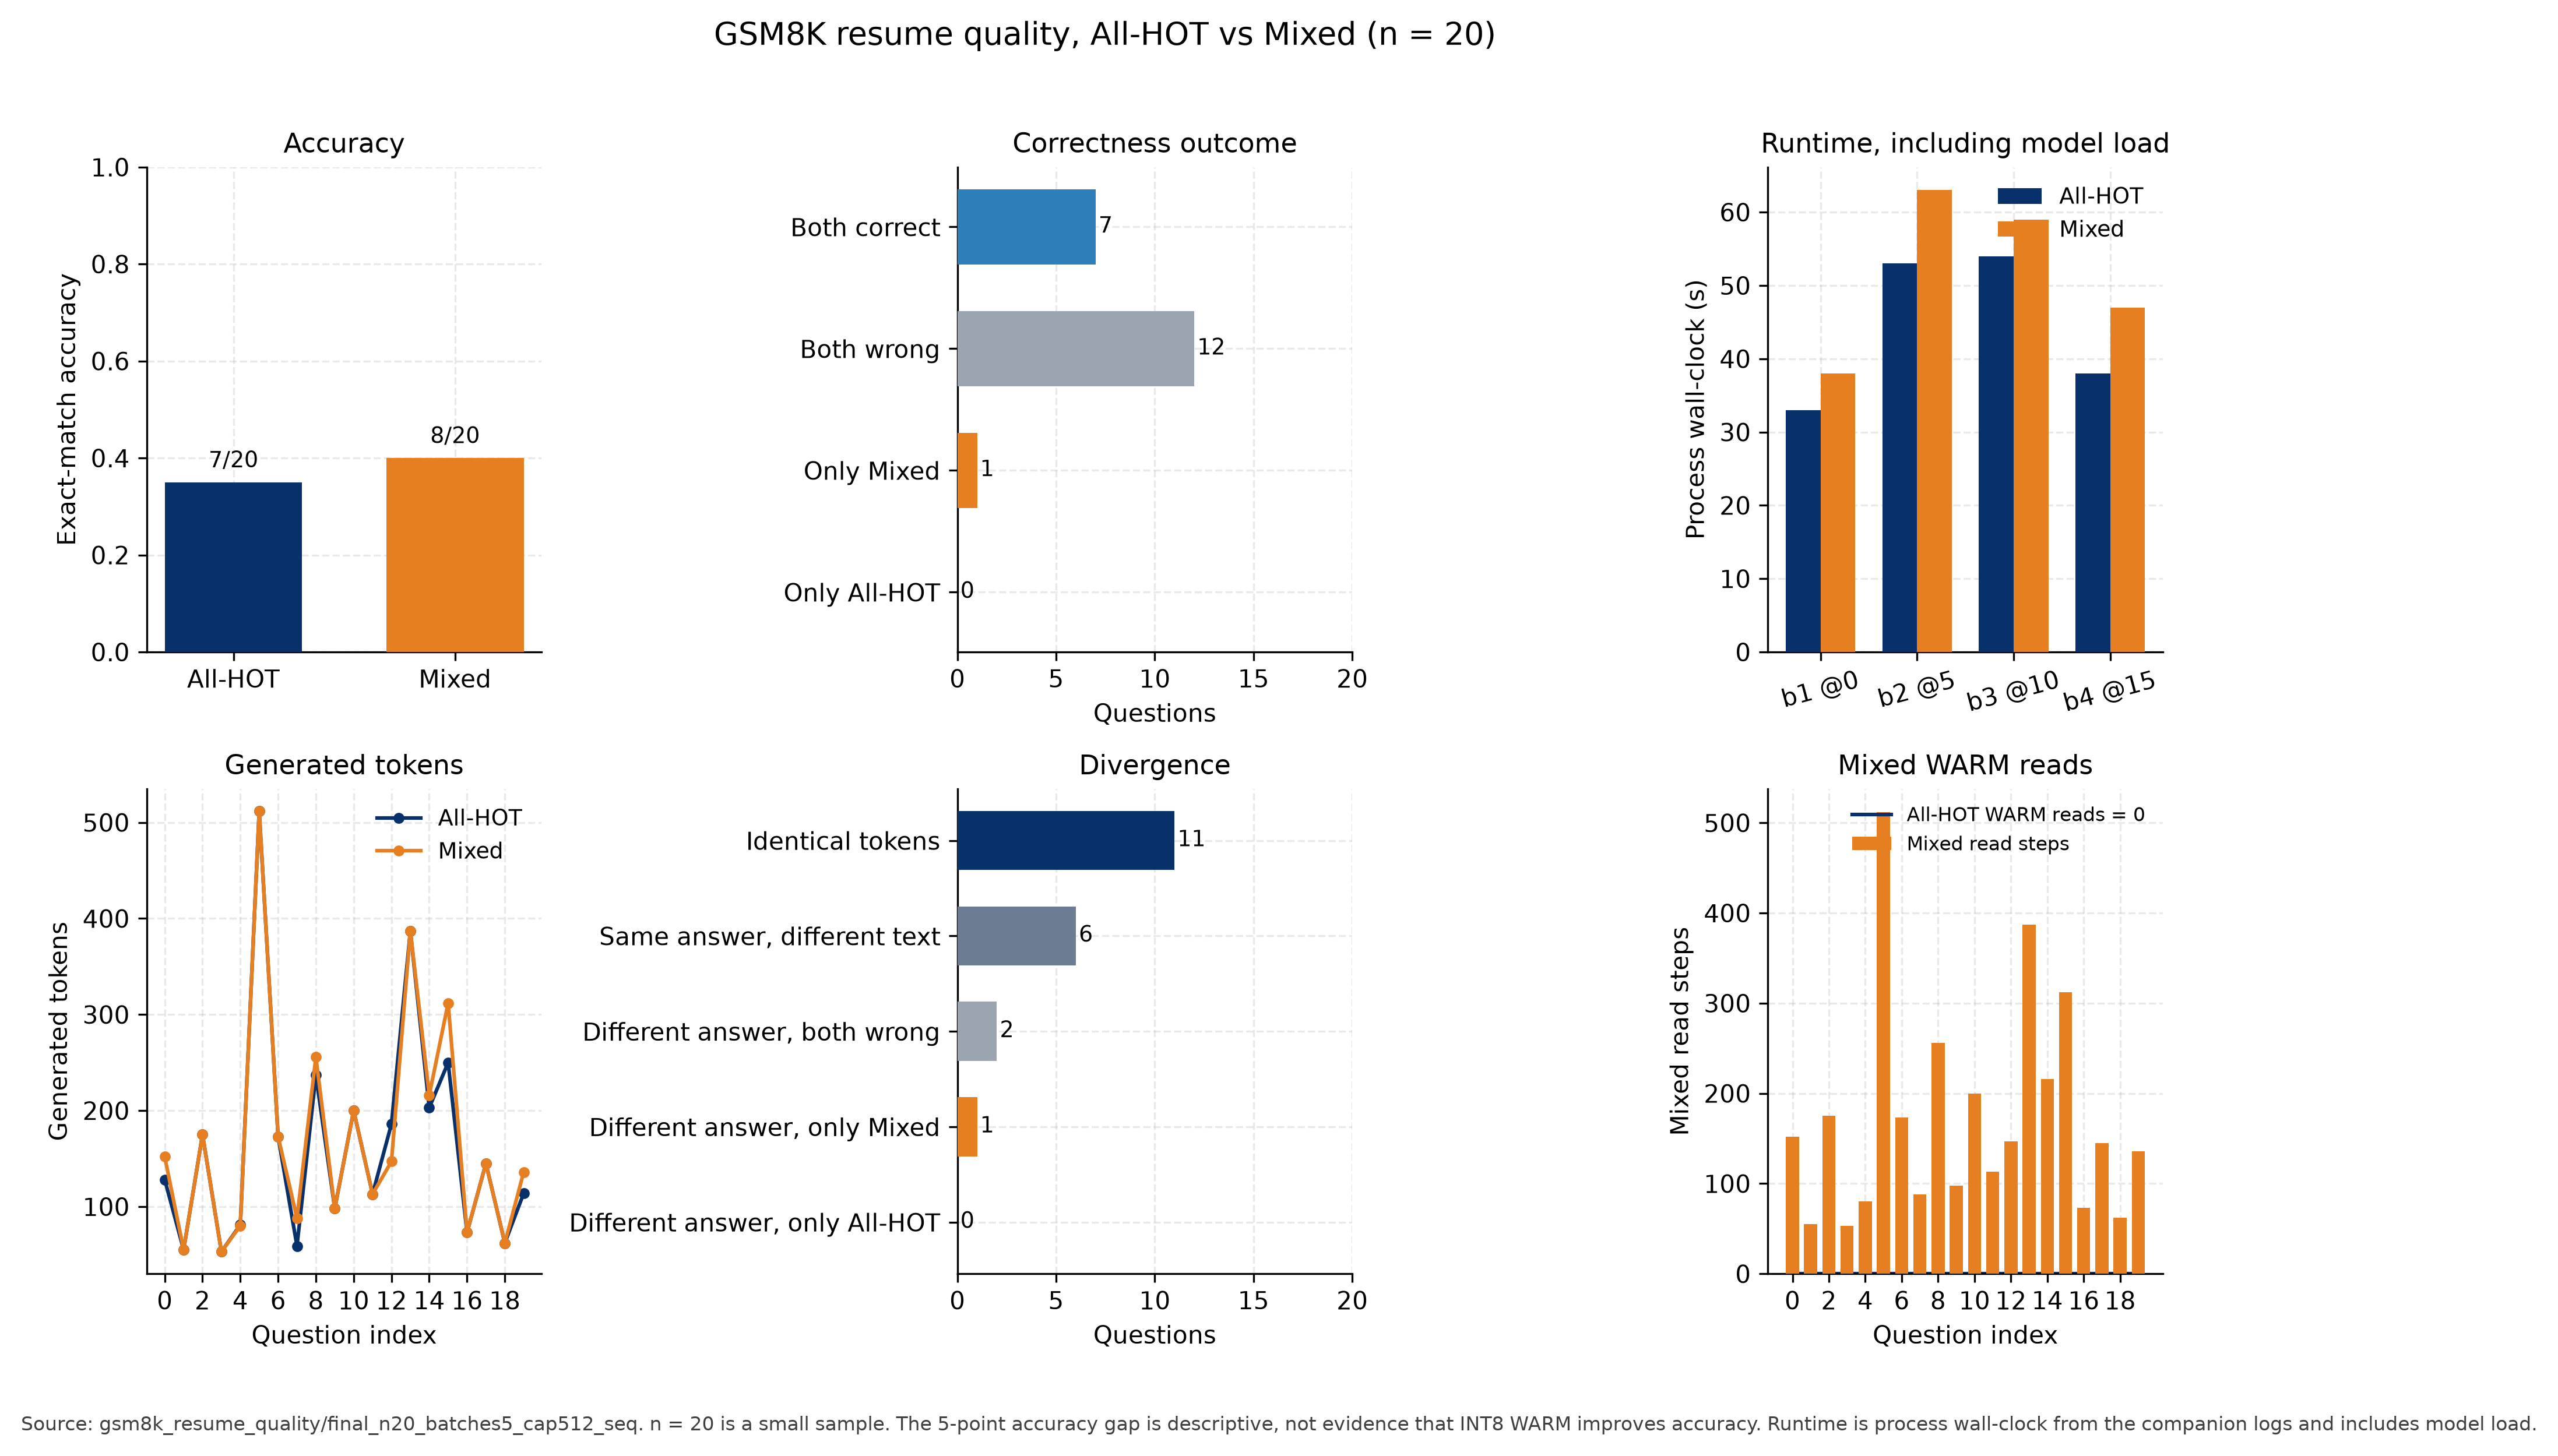

wrote experiments/hkv_pressure_study/plots/gsm8k_resume_quality.png
wrote experiments/hkv_pressure_study/plots/gsm8k_resume_quality.pdf


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12.4, 7.6))

accuracy_ax = axes[0, 0]
acc_modes = ["all-hot", "mixed"]
acc_values = [float(quality.loc[quality["mode"] == mode, "accuracy"].iloc[0]) for mode in acc_modes]
acc_counts = [int(quality.loc[quality["mode"] == mode, "exact_match"].iloc[0]) for mode in acc_modes]
accuracy_ax.bar(
    [MODE_LABELS[mode] for mode in acc_modes],
    acc_values,
    color=[MODE_COLORS[mode] for mode in acc_modes],
    width=0.62,
    zorder=3,
)
for x, value, count in zip((0, 1), acc_values, acc_counts):
    accuracy_ax.text(x, value + 0.02, f"{count}/20", ha="center", va="bottom", fontsize=9)
accuracy_ax.set_ylim(0, 1.0)
accuracy_ax.set_ylabel("Exact-match accuracy")
accuracy_ax.set_title("Accuracy")

outcome_ax = axes[0, 1]
outcome_labels = ["Both correct", "Both wrong", "Only Mixed", "Only All-HOT"]
outcome_values = [n_both_correct, n_both_wrong, n_only_mix, n_only_hot]
outcome_colors = ["#2c7fb8", "#9aa5b1", COLOR_MIXED, COLOR_ALL_HOT]
outcome_ax.barh(outcome_labels[::-1], outcome_values[::-1], color=outcome_colors[::-1], height=0.62, zorder=3)
for y, value in enumerate(outcome_values[::-1]):
    outcome_ax.text(value + 0.15, y, str(value), va="center", fontsize=9)
outcome_ax.set_xlim(0, 20)
outcome_ax.set_xlabel("Questions")
outcome_ax.set_title("Correctness outcome")

runtime_ax = axes[0, 2]
batches = list(EXPECTED_BATCHES)
x = range(len(batches))
width = 0.36
for offset, mode in ((-width / 2, "all-hot"), (width / 2, "mixed")):
    heights = [
        float(files.loc[(files["batch"] == batch) & (files["mode"] == mode), "log_wall_seconds"].iloc[0])
        for batch in batches
    ]
    runtime_ax.bar(
        [item + offset for item in x],
        heights,
        width=width,
        color=MODE_COLORS[mode],
        label=MODE_LABELS[mode],
        zorder=3,
    )
runtime_ax.set_xticks(list(x), [name.replace("batch_", "b").replace("_start_", " @") for name in batches], rotation=15)
runtime_ax.set_ylabel("Process wall-clock (s)")
runtime_ax.set_title("Runtime, including model load")
runtime_ax.legend()

token_ax = axes[1, 0]
token_ax.plot(
    paired["question_index"],
    paired["all_hot_generated_token_count"],
    color=COLOR_ALL_HOT,
    marker="o",
    markersize=3.5,
    label="All-HOT",
)
token_ax.plot(
    paired["question_index"],
    paired["mixed_generated_token_count"],
    color=COLOR_MIXED,
    marker="o",
    markersize=3.5,
    label="Mixed",
)
token_ax.set_xlabel("Question index")
token_ax.set_ylabel("Generated tokens")
token_ax.set_title("Generated tokens")
token_ax.set_xticks(range(0, 20, 2))
token_ax.legend()

div_ax = axes[1, 1]
div_labels = [
    "Identical tokens",
    "Same answer, different text",
    "Different answer, both wrong",
    "Different answer, only Mixed",
    "Different answer, only All-HOT",
]
div_values = [
    n_identical_tokens,
    n_same_answer_diff,
    int((paired["pair_class"] == "divergent_same_correctness").sum()),
    n_only_mix,
    n_only_hot,
]
div_ax.barh(div_labels[::-1], div_values[::-1], color=["#08306b", "#6b7c93", "#9aa5b1", COLOR_MIXED, "#c6d4e1"][::-1], height=0.62, zorder=3)
for y, value in enumerate(div_values[::-1]):
    div_ax.text(value + 0.15, y, str(value), va="center", fontsize=9)
div_ax.set_xlim(0, 20)
div_ax.set_xlabel("Questions")
div_ax.set_title("Divergence")

warm_ax = axes[1, 2]
warm_ax.bar(
    paired["question_index"],
    paired["mixed_read_steps"],
    color=COLOR_MIXED,
    width=0.72,
    zorder=3,
    label="Mixed read steps",
)
warm_ax.plot(
    paired["question_index"],
    paired["all_hot_generated_token_count"] * 0,
    color=COLOR_ALL_HOT,
    linewidth=1.5,
    label="All-HOT WARM reads = 0",
)
warm_ax.set_xlabel("Question index")
warm_ax.set_ylabel("Mixed read steps")
warm_ax.set_title("Mixed WARM reads")
warm_ax.set_xticks(range(0, 20, 2))
warm_ax.legend(fontsize=8)

fig.suptitle("GSM8K resume quality, All-HOT vs Mixed (n = 20)", fontsize=13, y=1.02)
fig.text(
    0.0,
    -0.03,
    "Source: gsm8k_resume_quality/final_n20_batches5_cap512_seq. "
    "n = 20 is a small sample. The 5-point accuracy gap is descriptive, not evidence that INT8 WARM improves accuracy. "
    "Runtime is process wall-clock from the companion logs and includes model load.",
    ha="left",
    va="top",
    fontsize=8,
    color="0.25",
)
fig.tight_layout()
plot_paths = []
for suffix in ("png", "pdf"):
    path = PLOTS / f"gsm8k_resume_quality.{suffix}"
    fig.savefig(path)
    plot_paths.append(path)
plt.close(fig)
display(Image(filename=str(plot_paths[0])))
for path in plot_paths:
    print("wrote", rel(path))


The figure shows the same counts as the tables: Mixed is one question higher
on exact match, most questions share a correctness outcome, Mixed generates
slightly more tokens, and every Mixed question records WARM read steps while
All-HOT records none. The runtime panel is batch process time, not decode latency.


## 7. Evidence that Mixed used the physical WARM INT8 path

Counts in this section come from the JSON. `warm_dtype` is the configured WARM
element type. `warm_residency` is the pre-resume list of logical blocks placed
in WARM slots. `mixed_read_steps` counts generation steps that read those slots.
`peak_warm_blocks` is the observed WARM-resident peak, which includes ballast
beyond the five evaluated questions. A HOT-reclaim counter is not in the schema;
the pre-resume snapshot is checked directly for null-backed block ids.


In [7]:
mixed_files = files[files["mode"] == "mixed"].copy()
mixed_sessions = sessions[sessions["mode"] == "mixed"].copy()
hkv_questions = mixed_sessions[
    [
        "batch",
        "question_index",
        "session_id",
        "complete_historical_blocks",
        "warm_residency_blocks",
        "warm_logical_blocks_observed",
        "mixed_read_steps",
        "generated_token_count",
        "pre_resume_warm_confirmed",
        "attention_had_warm_slots",
        "warm_logical_block_ids_zero",
        "temporary_shadow_hot_ids_set",
        "eligible",
    ]
].copy()
hkv_questions["residency_covers_complete_blocks"] = (
    hkv_questions["warm_residency_blocks"] == hkv_questions["complete_historical_blocks"]
)
hkv_questions["reads_cover_generation"] = (
    hkv_questions["mixed_read_steps"] == hkv_questions["generated_token_count"]
)

batch_hkv = mixed_files[
    [
        "batch",
        "warm_dtype",
        "warm_dtype_bytes",
        "warm_observed",
        "peak_warm_blocks",
        "peak_warm_requests",
        "peak_owned_warm_slots",
        "warm_kv_storage_bytes",
        "hot_to_warm_map_storage_bytes",
        "final_warm_blocks",
        "cleanup_complete",
        "allocator_consistent",
        "num_ballast_sessions_planned",
        "log_hot_to_warm_transitions",
        "log_hot_to_warm_changed_blocks",
    ]
].copy()
residency_by_batch = mixed_sessions.groupby("batch")["warm_residency_blocks"].sum()
batch_hkv["evaluated_warm_residency_blocks"] = batch_hkv["batch"].map(residency_by_batch)
batch_hkv["warm_blocks_beyond_evaluated_questions"] = (
    batch_hkv["peak_warm_blocks"] - batch_hkv["evaluated_warm_residency_blocks"]
)

assert set(mixed_files["warm_dtype"]) == {"int8"}
assert (mixed_files["warm_dtype_bytes"] == 1).all()
assert mixed_files["warm_observed"].all()
assert (mixed_files["warm_kv_storage_bytes"] > 0).all()
assert (mixed_files["hot_to_warm_map_storage_bytes"] > 0).all()
assert (mixed_files["final_warm_blocks"] == 0).all()
assert mixed_files["cleanup_complete"].all()
assert mixed_files["allocator_consistent"].all()
assert hkv_questions["pre_resume_warm_confirmed"].all()
assert hkv_questions["attention_had_warm_slots"].all()
assert hkv_questions["eligible"].all()
assert hkv_questions["residency_covers_complete_blocks"].all()
assert (hkv_questions["mixed_read_steps"] > 0).all()
assert hkv_questions["reads_cover_generation"].all()
assert (hkv_questions["warm_logical_blocks_observed"] == hkv_questions["complete_historical_blocks"]).all()
assert int(hkv_questions["warm_logical_block_ids_zero"].sum()) == 0
assert (
    hkv_questions["temporary_shadow_hot_ids_set"] == hkv_questions["warm_residency_blocks"]
).all()
assert (files.loc[files["mode"] == "all-hot", "warm_observed"] == False).all()
assert (files.loc[files["mode"] == "all-hot", "warm_kv_storage_bytes"] == 0).all()
assert (mixed_files["log_hot_to_warm_changed_blocks"] == mixed_files["peak_warm_blocks"]).all()

print("Mixed batch HKV records")
display(batch_hkv)
print(
    "evaluated questions with WARM residency:",
    int(hkv_questions["residency_covers_complete_blocks"].sum()),
    "/ 20",
)
print(
    "HOT-to-WARM residency entries on evaluated questions:",
    int(hkv_questions["warm_residency_blocks"].sum()),
)
print(
    "WARM read steps on evaluated questions:",
    int(hkv_questions["mixed_read_steps"].sum()),
)
print(
    "pre-resume logical blocks with block_id 0 (null-backed reclaim signal):",
    int(hkv_questions["warm_logical_block_ids_zero"].sum()),
)
print(
    "residency entries that still carry temporary_shadow_hot_block_id:",
    int(hkv_questions["temporary_shadow_hot_ids_set"].sum()),
    "/",
    int(hkv_questions["warm_residency_blocks"].sum()),
)
print("All-HOT warm_observed is false and warm_kv_storage_bytes is 0 in every All-HOT batch.")


Mixed batch HKV records


,batch,warm_dtype,warm_dtype_bytes,warm_observed,peak_warm_blocks,peak_warm_requests,peak_owned_warm_slots,warm_kv_storage_bytes,hot_to_warm_map_storage_bytes,final_warm_blocks,cleanup_complete,allocator_consistent,num_ballast_sessions_planned,log_hot_to_warm_transitions,log_hot_to_warm_changed_blocks,evaluated_warm_residency_blocks,warm_blocks_beyond_evaluated_questions
1,batch_1_start_0,int8,1,True,357,6,357,968884224,170128,0,True,True,8,6,357,232,125
3,batch_2_start_5,int8,1,True,358,6,358,968884224,170128,0,True,True,8,6,358,234,124
5,batch_3_start_10,int8,1,True,358,6,358,968884224,170128,0,True,True,8,6,358,233,125
7,batch_4_start_15,int8,1,True,358,6,358,968884224,170128,0,True,True,8,6,358,233,125


evaluated questions with WARM residency: 20 / 20
HOT-to-WARM residency entries on evaluated questions: 932
WARM read steps on evaluated questions: 3433
pre-resume logical blocks with block_id 0 (null-backed reclaim signal): 0
residency entries that still carry temporary_shadow_hot_block_id: 932 / 932
All-HOT warm_observed is false and warm_kv_storage_bytes is 0 in every All-HOT batch.


Mixed did exercise physical WARM INT8. Each Mixed file records `warm_dtype`
`int8`, a 968,884,224-byte WARM pool, a non-zero HOT-to-WARM map, and
`warm_observed=true`. All 20 evaluated questions were WARM-resident before
resume: residency length equals `complete_historical_blocks`, and
`mixed_read_steps` equals the number of generated tokens. Peak WARM occupancy
is 357 or 358 blocks, above the evaluated-question residency, with
`peak_warm_requests=6` against five questions. The companion logs name the same
event `hot->warm`, and their `changed_blocks` totals equal `peak_warm_blocks`.

The JSON does not record reclaimed HOT blocks. At the pre-resume snapshot every
warm logical position still has a non-zero block id and a
`temporary_shadow_hot_block_id`. `final_warm_blocks=0` with
`cleanup_complete=true` means WARM was released after the run, which is cleanup
rather than a counted HOT reclaim.


## 8. The failed 100-question attempt

`final_n100_batches5_cap512_seq` is read here and then left out of every table
above. A missing result JSON is not treated as a scored question.


In [8]:
failed_marker = FAILED_DIR / "FAILED.txt"
failed_children = sorted(path.relative_to(FAILED_DIR) for path in FAILED_DIR.rglob("*") if path.is_file())
print("failure directory:", rel(FAILED_DIR))
print("files:")
for path in failed_children:
    print(" ", path)
marker_text = failed_marker.read_text(encoding="utf-8").strip()
print("FAILED.txt:", marker_text)
log_paths = list(FAILED_DIR.rglob("*.log"))
json_paths = list(FAILED_DIR.rglob("*.json"))
assert not json_paths, json_paths
assert log_paths, "expected the batch-1 All-HOT log"
failure_log = log_paths[0]
failure_text = failure_log.read_text(encoding="utf-8", errors="replace")
print("log:", rel(failure_log))
print(failure_text)
assert "ModuleNotFoundError: No module named 'experiments'" in failure_text
assert "all_hot" in failure_log.name

n20_end = max(payload["timing"]["end"] for payload in loaded.values())
print("latest final-n20 timing.end:", n20_end)
print("n100 produced no session JSON, so it is excluded from the 20-question aggregate.")


failure directory: experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq
files:
  FAILED.txt
  batch_01_start_000/all_hot.log
FAILED.txt: FAILED batch 1 All-HOT at Mon Sep 21 11:09:00 PM IDT 2026
log: experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n100_batches5_cap512_seq/batch_01_start_000/all_hot.log
Traceback (most recent call last):
  File "/home/shani.dayan/kv_cache_project/experiments/scripts/run_hkv_gsm8k_resume_quality.py", line 16, in <module>
    from experiments.scripts.hkv_gsm8k import (
ModuleNotFoundError: No module named 'experiments'

latest final-n20 timing.end: 2026-09-21T19:59:11.653451+00:00
n100 produced no session JSON, so it is excluded from the 20-question aggregate.


The 100-question run failed in batch 1 All-HOT before any result JSON was
written. `FAILED.txt` records `FAILED batch 1 All-HOT at Mon Sep 21 11:09:00 PM IDT 2026`.
The only log, `batch_01_start_000/all_hot.log`, is the traceback
`ModuleNotFoundError: No module named 'experiments'` from
`experiments/scripts/run_hkv_gsm8k_resume_quality.py`. The process never reached
generation. The completed 20-question directory already had `timing.end` values
through `2026-09-21T19:59:11Z`, earlier that evening, and its eight JSON files
validate. This import failure does not change those files and does not belong
in the quality aggregate.


## 9. Comparison with the existing tables

The on-disk CSVs are loaded before this notebook writes anything. Shared quality
fields are compared to the JSON aggregate. Per-question and divergent-answer
tables are compared on their existing columns. This notebook then rewrites the
summary with the same original rows plus the token, completion, and wall-clock
rows computed above, and rewrites the other two CSVs only if a shared value
disagrees.


In [9]:
SUMMARY_PATH = TABLES / "gsm8k_quality_summary.csv"
PER_QUESTION_PATH = TABLES / "gsm8k_per_question.csv"
DIVERGENT_PATH = TABLES / "gsm8k_divergent_answers.csv"

existing_summary = pd.read_csv(SUMMARY_PATH)
existing_per_question = pd.read_csv(PER_QUESTION_PATH)
existing_divergent = pd.read_csv(DIVERGENT_PATH)


def as_rate(value):
    if value is None or (isinstance(value, float) and math.isnan(value)):
        return None
    return round(float(value), 10)


computed_summary_rows = [
    {"metric": "n_questions", "value": 20, "rate": pd.NA},
    {"metric": "all_hot_exact_match", "value": int(hot["exact_match"].sum()), "rate": int(hot["exact_match"].sum()) / 20},
    {"metric": "mixed_exact_match", "value": int(mix["exact_match"].sum()), "rate": int(mix["exact_match"].sum()) / 20},
    {"metric": "all_hot_parse_failures", "value": int(hot["parse_failure"].sum()), "rate": pd.NA},
    {"metric": "mixed_parse_failures", "value": int(mix["parse_failure"].sum()), "rate": pd.NA},
    {"metric": "identical_extracted_answers", "value": n_identical_extracted, "rate": n_identical_extracted / 20},
    {"metric": "divergent_extracted_answers", "value": n_divergent_extracted, "rate": n_divergent_extracted / 20},
    {"metric": "only_all_hot_correct", "value": n_only_hot, "rate": pd.NA},
    {"metric": "only_mixed_correct", "value": n_only_mix, "rate": pd.NA},
    {"metric": "both_correct", "value": n_both_correct, "rate": pd.NA},
    {"metric": "both_wrong", "value": n_both_wrong, "rate": pd.NA},
    {
        "metric": "divergent_same_correctness_outcome",
        "value": int((paired["pair_class"] == "divergent_same_correctness").sum()),
        "rate": pd.NA,
    },
    {"metric": "mixed_questions_eligible", "value": int(mix["eligible"].sum()), "rate": pd.NA},
    {"metric": "async_scheduling", "value": True, "rate": pd.NA},
    {"metric": "sequential_resume", "value": True, "rate": pd.NA},
    {
        "metric": "note",
        "value": (
            "n=20 is a small sample; the 5-percentage-point exact-match "
            "difference is descriptive, not evidence that quantization "
            "improves accuracy."
        ),
        "rate": pd.NA,
    },
]
computed_summary = pd.DataFrame(computed_summary_rows)
existing_by_metric = existing_summary.set_index("metric")
summary_mismatches = []
for row in computed_summary.itertuples(index=False):
    if row.metric not in existing_by_metric.index:
        summary_mismatches.append(f"missing metric in existing CSV: {row.metric}")
        continue
    old = existing_by_metric.loc[row.metric]
    old_value = old["value"]
    if row.metric == "note":
        if str(old_value) != str(row.value):
            summary_mismatches.append("note text differs")
        continue
    if str(old_value) != str(row.value) and not (
        isinstance(row.value, bool) and str(old_value) == str(row.value)
    ):
        try:
            if float(old_value) != float(row.value):
                summary_mismatches.append(f"{row.metric} value {old_value} != {row.value}")
        except (TypeError, ValueError):
            summary_mismatches.append(f"{row.metric} value {old_value} != {row.value}")
    old_rate = old["rate"] if "rate" in old else pd.NA
    new_rate = row.rate
    if pd.isna(new_rate):
        if pd.notna(old_rate):
            summary_mismatches.append(f"{row.metric} rate present in CSV but not recomputed")
    elif pd.isna(old_rate) or abs(float(old_rate) - float(new_rate)) > 1e-12:
        summary_mismatches.append(f"{row.metric} rate {old_rate} != {new_rate}")

per_export = sessions.drop(
    columns=[
        "generated_token_ids",
        "extraction_success",
        "status",
        "warm_residency_blocks",
        "warm_logical_block_ids_zero",
        "temporary_shadow_hot_ids_set",
    ]
)[
    [
        "batch",
        "mode",
        "session_id",
        "question_index",
        "gold_value",
        "extracted_value",
        "exact_match",
        "parse_failure",
        "final_text",
        "generated_token_count",
        "mixed_read_steps",
        "warm_logical_blocks_observed",
        "pre_resume_warm_confirmed",
        "eligible",
        "exclusion_reason",
        "completed_turns",
        "error",
    ]
].sort_values(["question_index", "mode"]).reset_index(drop=True)

divergent_export = paired.loc[~paired["extracted_equal"]].copy()
divergent_export["identical_extracted"] = False
divergent_export["pair_class"] = divergent_export["pair_class"].map(
    {
        "divergent_same_correctness": "divergent_same_correctness",
        "divergent_only_mixed_correct": "divergent_only_mixed_correct",
        "divergent_only_all_hot_correct": "divergent_only_all_hot_correct",
    }
)
divergent_export = divergent_export[
    [
        "question_index",
        "session_id",
        "batch",
        "gold_value",
        "all_hot_extracted",
        "mixed_extracted",
        "all_hot_exact_match",
        "mixed_exact_match",
        "all_hot_parse_failure",
        "mixed_parse_failure",
        "identical_extracted",
        "pair_class",
        "all_hot_generated_token_count",
        "mixed_generated_token_count",
        "mixed_read_steps",
        "warm_logical_blocks_observed",
        "all_hot_final_text",
        "mixed_final_text",
    ]
].sort_values("question_index").reset_index(drop=True)


def frame_mismatches(existing: pd.DataFrame, computed: pd.DataFrame, keys: list[str]) -> list[str]:
    left = existing.copy()
    right = computed.copy()
    for frame in (left, right):
        for column in frame.columns:
            if frame[column].dtype == bool:
                frame[column] = frame[column].astype(str)
    left = left.sort_values(keys).reset_index(drop=True)
    right = right.sort_values(keys).reset_index(drop=True)
    mismatches = []
    if list(left.columns) != list(right.columns):
        mismatches.append(f"columns {list(left.columns)} != {list(right.columns)}")
        return mismatches
    if len(left) != len(right):
        mismatches.append(f"row count {len(left)} != {len(right)}")
    shared = min(len(left), len(right))
    for column in left.columns:
        for idx in range(shared):
            a = left.iloc[idx][column]
            b = right.iloc[idx][column]
            a_missing = pd.isna(a)
            b_missing = pd.isna(b)
            if a_missing and b_missing:
                continue
            if a_missing != b_missing or str(a) != str(b):
                try:
                    if abs(float(a) - float(b)) <= 1e-9:
                        continue
                except (TypeError, ValueError):
                    pass
                mismatches.append(f"row {idx} column {column}: {a!r} != {b!r}")
                if len(mismatches) >= 8:
                    return mismatches
    return mismatches


per_mismatches = frame_mismatches(existing_per_question, per_export, ["question_index", "mode"])
div_mismatches = frame_mismatches(existing_divergent, divergent_export, ["question_index"])
print("quality-summary mismatches:", summary_mismatches or "none")
print("per-question mismatches:", per_mismatches or "none")
print("divergent-answer mismatches:", div_mismatches or "none")

extra_summary = pd.DataFrame(
    [
        {"metric": "all_hot_completed", "value": 20, "rate": pd.NA},
        {"metric": "mixed_completed", "value": 20, "rate": pd.NA},
        {"metric": "all_hot_failed", "value": 0, "rate": pd.NA},
        {"metric": "mixed_failed", "value": 0, "rate": pd.NA},
        {"metric": "all_hot_timed_out", "value": 0, "rate": pd.NA},
        {"metric": "mixed_timed_out", "value": 0, "rate": pd.NA},
        {"metric": "all_hot_extraction_success", "value": int(hot["extraction_success"].sum()), "rate": int(hot["extraction_success"].sum()) / 20},
        {"metric": "mixed_extraction_success", "value": int(mix["extraction_success"].sum()), "rate": int(mix["extraction_success"].sum()) / 20},
        {"metric": "all_hot_generated_tokens", "value": int(hot["generated_token_count"].sum()), "rate": pd.NA},
        {"metric": "mixed_generated_tokens", "value": int(mix["generated_token_count"].sum()), "rate": pd.NA},
        {"metric": "all_hot_avg_generated_tokens", "value": float(hot["generated_token_count"].mean()), "rate": pd.NA},
        {"metric": "mixed_avg_generated_tokens", "value": float(mix["generated_token_count"].mean()), "rate": pd.NA},
        {"metric": "all_hot_log_wall_seconds", "value": float(files.loc[files["mode"] == "all-hot", "log_wall_seconds"].sum()), "rate": pd.NA},
        {"metric": "mixed_log_wall_seconds", "value": float(files.loc[files["mode"] == "mixed", "log_wall_seconds"].sum()), "rate": pd.NA},
        {"metric": "identical_token_sequences", "value": n_identical_tokens, "rate": n_identical_tokens / 20},
        {"metric": "both_correct_different_text", "value": n_both_correct_diff, "rate": pd.NA},
        {"metric": "warm_dtype", "value": "int8", "rate": pd.NA},
        {"metric": "mixed_warm_kv_storage_bytes", "value": int(mixed_files["warm_kv_storage_bytes"].max()), "rate": pd.NA},
        {"metric": "null_backed_hot_blocks_at_pre_resume", "value": int(hkv_questions["warm_logical_block_ids_zero"].sum()), "rate": pd.NA},
    ]
)
summary_out = pd.concat([computed_summary, extra_summary], ignore_index=True)
summary_out.to_csv(SUMMARY_PATH, index=False)
print("updated", rel(SUMMARY_PATH), "with", len(extra_summary), "additional rows")

written = [rel(SUMMARY_PATH)]
if per_mismatches:
    per_export.to_csv(PER_QUESTION_PATH, index=False)
    written.append(rel(PER_QUESTION_PATH))
    print("updated", rel(PER_QUESTION_PATH), "because shared values disagreed")
else:
    print("left", rel(PER_QUESTION_PATH), "unchanged; shared columns match the JSON")
if div_mismatches:
    divergent_export.to_csv(DIVERGENT_PATH, index=False)
    written.append(rel(DIVERGENT_PATH))
    print("updated", rel(DIVERGENT_PATH), "because shared values disagreed")
else:
    print("left", rel(DIVERGENT_PATH), "unchanged; shared columns match the JSON")
assert not summary_mismatches
assert not per_mismatches
assert not div_mismatches


quality-summary mismatches: none
per-question mismatches: none
divergent-answer mismatches: none
updated experiments/hkv_pressure_study/tables/gsm8k_quality_summary.csv with 19 additional rows
left experiments/hkv_pressure_study/tables/gsm8k_per_question.csv unchanged; shared columns match the JSON
left experiments/hkv_pressure_study/tables/gsm8k_divergent_answers.csv unchanged; shared columns match the JSON


The previous summary, per-question table, and divergent-answer table match the
recomputed JSON on every shared field: 7 and 8 exact matches, one parse failure
in each mode, 17 identical extracted answers, 3 divergent extracted answers,
0 only-All-HOT, 1 only-Mixed, 7 both correct, and 12 both wrong. The summary
CSV is extended with completion, token, wall-clock, and WARM rows that the
older file did not contain. No shared value had to be corrected.


## 10. What to preserve, and what is not a final result

The cell below lists every directory under `runs/gsm8k_resume_quality/` and
marks the one directory whose JSON enters the tables.


In [10]:
rows = []
for path in sorted(RUNS.iterdir()):
    if not path.is_dir():
        continue
    json_count = len(list(path.rglob("*.json")))
    if path.name == FINAL_DIR.name:
        role = "final aggregate"
    elif path.name == FAILED_DIR.name:
        role = "failed attempt; keep the marker and log, exclude from statistics"
    elif path.name.startswith("smoke") or "debug" in path.name or "retry" in path.name:
        role = "smoke, debug, or retry; do not present as final"
    elif path.name.startswith("preflight"):
        role = "preflight; do not present as final"
    elif "sync" in path.name:
        role = "synchronous-scheduling trial; do not present as final"
    else:
        role = "earlier or partial run; do not present as final"
    rows.append({"directory": path.name, "json_files": json_count, "role": role})
inventory = pd.DataFrame(rows)
display(inventory)
print("preserve these result JSON files:")
for batch_name in EXPECTED_BATCHES:
    for filename in ("all_hot.json", "mixed.json"):
        print(" ", rel(FINAL_DIR / batch_name / filename))
print("preserve the failure record, outside the aggregate:")
print(" ", rel(FAILED_DIR / "FAILED.txt"))
print(" ", rel(FAILED_DIR / "batch_01_start_000" / "all_hot.log"))


,directory,json_files,role
0,final_n100_batches5_cap512_seq,0,"failed attempt; keep the marker and log, exclude from statistics"
1,final_n20_batches5,8,earlier or partial run; do not present as final
2,final_n20_batches5_cap512_seq,8,final aggregate
3,final_q5_cap512_seq_rep1,1,earlier or partial run; do not present as final
4,final_q5_cap512_seq_v2_rep1,2,earlier or partial run; do not present as final
5,final_q5_cap512_sync_rep1,3,synchronous-scheduling trial; do not present as final
6,preflight,2,preflight; do not present as final
7,preflight_scale,6,preflight; do not present as final
8,smoke_q4_shots5,2,"smoke, debug, or retry; do not present as final"
9,smoke_q4_shots5_v2,4,"smoke, debug, or retry; do not present as final"


preserve these result JSON files:
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_1_start_0/all_hot.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_1_start_0/mixed.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_2_start_5/all_hot.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_2_start_5/mixed.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_3_start_10/all_hot.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_3_start_10/mixed.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_4_start_15/all_hot.json
  experiments/hkv_pressure_study/runs/gsm8k_resume_quality/final_n20_batches5_cap512_seq/batch_4_start_15/mixed.json
preserve the failure recor

Preserve the eight JSON files in `final_n20_batches5_cap512_seq/batch_*` as the
quality record, plus `FAILED.txt` and `batch_01_start_000/all_hot.log` as the
record of why the 100-question attempt stopped. Do not present
`final_n20_batches5` (the earlier 64-token run), `final_q5_*`, `smoke_*`,
`preflight`, `preflight_scale`, or the failed `final_n100_batches5_cap512_seq`
directory as the final GSM8K result.


## Key findings

Mixed preserved answer quality on this 20-question run in the limited sense
that correctness changed for only one question. All-HOT exact match is 7/20
and Mixed exact match is 8/20. The one-question gap is descriptive. It is not
evidence that INT8 WARM improves accuracy.

Nine outputs diverged in token sequence. Six of those still extracted the same
integer, including three questions that are correct in both modes despite
different text (0, 10, and 14). Extracted answers differ on questions 7, 8,
and 15. Divergence changed correctness only on question 15, where Mixed is
correct and All-HOT is not. No question is correct only under All-HOT.

WARM INT8 was actually exercised. Every Mixed batch records `warm_dtype=int8`,
a 0.902 GiB WARM pool, HOT-to-WARM map storage, and `warm_observed=true`.
All 20 Mixed questions have pre-resume WARM residency covering their complete
historical blocks, and every generated Mixed token is a WARM read. Peak WARM
occupancy is 357–358 blocks. The pre-resume snapshot does not show reclaimed
HOT blocks: shadow HOT ids are still set and block ids are not zero.

The 100-question attempt is not part of these totals. It failed at import in
batch 1 All-HOT (`ModuleNotFoundError: No module named 'experiments'`) and
wrote no JSON.

Twenty questions, one model (`Qwen/Qwen3-0.6B`), and one seed are too small a
sample to claim quality equivalence or a quality gain. Question 5 is
unscored in both modes because generation hit the 512-token cap.
